EfficientNet refers to a family of CNN models (B0–B7) that you use for image classification, but these models were not designed manually—they were created using a smart compound scaling algorithm. This algorithm determines how to expand a model’s width, depth, and input resolution in a balanced and efficient way, so accuracy improves without wasting computation. The algorithm is used only during architecture design, while the thing you actually use is the pretrained EfficientNet model, loaded through TensorFlow (e.g., tf.keras.applications.EfficientNetB0(...)) for prediction and transfer learning.

In [5]:
!git clone -b EfficientNetB3_Peng https://github.com/seanmcgowanx/coral-reef-classification.git

fatal: destination path 'coral-reef-classification' already exists and is not an empty directory.


In [6]:
!pip install -q -r /content/coral-reef-classification/requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/coral-reef-classification/requirements.txt'


In [4]:
!rm -rf /content/drive #complete clean up and remount only when remount not successful


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!git clone https://github.com/seanmcgowanx/coral-reef-classification.git


Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 81 (delta 9), reused 25 (delta 5), pack-reused 47 (from 1)
Receiving objects: 100% (81/81), 63.12 MiB | 33.06 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [ ]:
# Import Configuration
import sys      # sys lets us modify the Python import path (sys.path)
import os       # os gives access to environment variables, paths, and directory operations

def in_colab():
    # Detect whether the code is running inside Google Colab.
    # Colab sets "COLAB_GPU" in environment variables OR loads "google.colab" module.
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    # If running in Google Colab:
    # Set the repository path to where GitHub repos are usually cloned in Colab.
    repo_path = "/content/coral-reef-classification"

    # Set the dataset path under the repo (processed data folder).
    data_path = "/content/coral-reef-classification/data/processed"
else:
    # If running on your local machine (e.g., VS Code):

    # repo_path = parent folder of the current working directory
    # os.getcwd() gives the current directory
    # os.path.join(..., "..") moves one folder upward
    # os.path.abspath cleans and converts to full absolute path
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

    # data_path = parent folder → data → processed
    data_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed"))

# Add repo_path to the Python module search path if it's not already included.
# This allows importing Python modules from the cloned repository.
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Print the paths being used so the user can verify correctness.
print("Using repo path:", repo_path)
print("Using data path:", data_path)


Using repo path: /content/coral-reef-classification
Using data path: /content/coral-reef-classification/data/processed


In [ ]:
# =====================================================================
#   FINAL PIPELINE — using repo multi-hot labels (CORRECT VERSION)
# =====================================================================

import os
import sys
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------
# 1. Detect Colab & set paths
# -----------------------------------------------------------
def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"
else:
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

print("Repo path:", repo_path)
print("Data path:", data_path)

# -----------------------------------------------------------
# 2. Load REPO multi-hot CSVs
# -----------------------------------------------------------
train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv  = os.path.join(data_path, "final_labels_test.csv")

df_train_full = pd.read_csv(train_csv)
df_test       = pd.read_csv(test_csv)

print("Loaded train:", df_train_full.shape)
print("Loaded test :", df_test.shape)

# -----------------------------------------------------------
# 3. Identify class columns
# -----------------------------------------------------------
NON_CLASS_COLS = ["image_id", "region_id", "region_name"]

CLASSES = [c for c in df_train_full.columns if c not in NON_CLASS_COLS]
print("\nDetected classes:", len(CLASSES))
print(CLASSES)

# -----------------------------------------------------------
# 4. Train → Train + Val split (5%)
# -----------------------------------------------------------
train_df, val_df = train_test_split(
    df_train_full,
    test_size=0.05,
    shuffle=True,
    random_state=42
)

print("\nTrain:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(df_test))

# -----------------------------------------------------------
# 5. Add filepaths from YOLO folder
# -----------------------------------------------------------
IMG_DIR = Path("/content/drive/My Drive/AAI-501-02/Final_project/dataset_yolov8_7class/images")

def find_image(image_id):
    for sub in ["train", "val", "test"]:
        for ext in ["png", "jpg", "jpeg"]:
            p = IMG_DIR / sub / f"{image_id}.{ext}"
            if p.exists():
                return str(p)
    return None

for df in [train_df, val_df, df_test]:
    df["filepath"] = df["image_id"].apply(find_image)

# remove images without actual files
train_df = train_df[train_df["filepath"].notna()]
val_df   = val_df[val_df["filepath"].notna()]
df_test  = df_test[df_test["filepath"].notna()]

# -----------------------------------------------------------
# 6. Save final multi-hot CSVs
# -----------------------------------------------------------
OUT_TRAIN = "/content/drive/My Drive/AAI-501-02/Final_project/train_multilabel.csv"
OUT_VAL   = "/content/drive/My Drive/AAI-501-02/Final_project/val_multilabel.csv"
OUT_TEST  = "/content/drive/My Drive/AAI-501-02/Final_project/test_multilabel.csv"

train_df.to_csv(OUT_TRAIN, index=False)
val_df.to_csv(OUT_VAL, index=False)
df_test.to_csv(OUT_TEST, index=False)

print("\nSaved CSVs:")
print(" Train →", OUT_TRAIN, len(train_df))
print(" Val   →", OUT_VAL,   len(val_df))
print(" Test  →", OUT_TEST,  len(df_test))


Repo path: /content/coral-reef-classification
Data path: /content/coral-reef-classification/data/processed
Loaded train: (2635, 18)
Loaded test : (2186, 18)

Detected classes: 16
['Macroalgae', 'Rubble', 'Crustose coralline algae', 'Bare substrate', 'Sand', 'Turf algae', 'Porites', 'Hard coral', 'Soft coral', 'Acropora', 'Tape', 'Pocillopora', 'Dead coral', 'Montipora', 'Cyanobacteria', 'Sponge']

Train: 2503
Val: 132
Test: 2186

Saved CSVs:
 Train → /content/drive/My Drive/AAI-501-02/Final_project/train_multilabel.csv 2503
 Val   → /content/drive/My Drive/AAI-501-02/Final_project/val_multilabel.csv 132
 Test  → /content/drive/My Drive/AAI-501-02/Final_project/test_multilabel.csv 2186


10 images WITHIN the repo 4821 that have 0 valid labels
16950ff1-7d4a-4275-8cc9-a10ee06445dc
3a375b2b-e872-4912-93d8-5182ba2de301
41ea9502-fb0f-471d-bc30-28593cdcdf94
4b5a4809-857d-47a7-a014-547322ec48cd
6cb09bb9-4865-4569-9d8e-f6bd712cd20d
710bd5ce-ff83-48b6-b3e7-6cb628d4ef93
83f648e8-565c-4290-98eb-738a23752d54
8b45642e-bebc-41a5-811f-04b4aa9b1d44
8f4e330c-1f2f-4bb5-95ee-647fbfa0c2aa
c8a32fed-edb4-41aa-be34-eed659870643


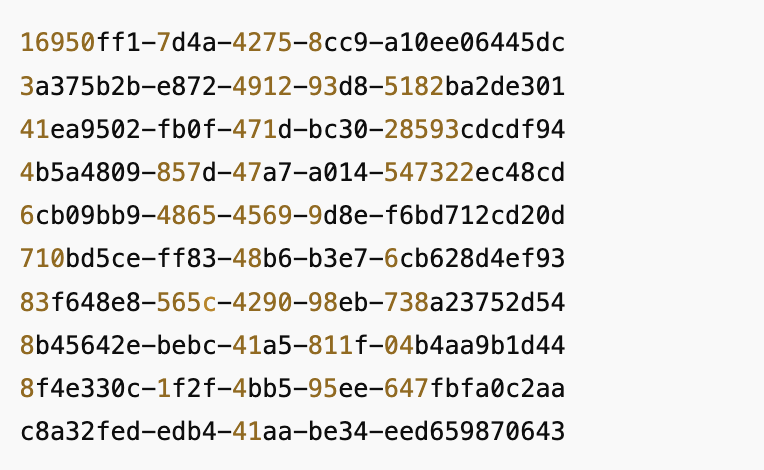

In [ ]:
# ============================================================
# EfficientNetB3 — Multi-Label Classification Pipeline (Oversample v4)
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models

# ============================================================
# 1. CONFIG
# ============================================================

TRAIN_CSV = "/content/drive/My Drive/AAI-501-02/Final_project/train_multilabel.csv"
VAL_CSV   = "/content/drive/My Drive/AAI-501-02/Final_project/val_multilabel.csv"
TEST_CSV  = "/content/drive/My Drive/AAI-501-02/Final_project/test_multilabel.csv"

IMG_ROOT = Path("/content/drive/My Drive/AAI-501-02/Final_project/dataset_yolov8_7class/images")

PATCH_SIZE = 300
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 15

CHECKPOINT_DIR = "/content/drive/My Drive/AAI-501-02/Final_project/effnet_multi_label_ckpt_B3_repo_oversample_v4"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

stage1_ckpt = f"{CHECKPOINT_DIR}/best_stage1.keras"
stage2_ckpt = f"{CHECKPOINT_DIR}/best_stage2.keras"


# ============================================================
# 2. LOAD CSVs AND FIX COLUMNS
# ============================================================

def load_split(csv_path):
    df = pd.read_csv(csv_path)

    if "region_name" in df.columns:
        df = df.drop(columns=["region_name"])

    # Build image path
    def find_img(image_id):
        for split in ["train", "val", "test"]:
            for ext in ["jpg", "png", "jpeg"]:
                fp = IMG_ROOT / split / f"{image_id}.{ext}"
                if fp.exists():
                    return str(fp)
        return None

    df["filepath"] = df["image_id"].apply(find_img)
    df = df[df["filepath"].notna()]

    class_cols = [c for c in df.columns if c not in ["image_id", "filepath"]]

    X = df["filepath"].values
    y = df[class_cols].values.astype("float32")

    return X, y, class_cols


X_train, y_train, CLASSES = load_split(TRAIN_CSV)
X_val,   y_val, _         = load_split(VAL_CSV)
X_test,  y_test, _        = load_split(TEST_CSV)

NUM_CLASSES = len(CLASSES)
print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("CLASSES:", CLASSES)


# ============================================================
# 3. FAST IMAGE LOADER
# ============================================================

def load_image(path, label):
    img = tf.io.read_file(path)

    # detect file type
    if tf.strings.regex_full_match(path, ".*\\.png"):
        img = tf.image.decode_png(img, channels=3)
    else:
        img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (PATCH_SIZE, PATCH_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label


# ============================================================
# 4. CORRECT MULTI-LABEL OVERSAMPLING
# ============================================================

# per-class frequency
class_counts = y_train.sum(axis=0)
freq = class_counts / len(y_train)

# inverse frequency for weighting
class_weights = 1.0 / (freq + 1e-6)
class_weights = class_weights / class_weights.sum()

print("\nClass weights:", class_weights)

# per-sample weight = sum weights of labels present
sample_weights = (y_train * class_weights).sum(axis=1)

# normalize
sample_weights = sample_weights / sample_weights.sum()

# sampling indices
def sample_indices(n_samples):
    idx = np.random.choice(
        np.arange(len(X_train)),
        size=n_samples,
        replace=True,
        p=sample_weights
    )
    return idx

# create oversampled dataset
def make_oversample_ds(X, y, batch_size):
    def gen():
        while True:
            idx = sample_indices(batch_size)
            yield X[idx], y[idx]

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None,), dtype=tf.string),
            tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32),
        )
    )

    ds = ds.unbatch()
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_oversample_ds(X_train, y_train, BATCH_SIZE)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
)


# ============================================================
# 5. EfficientNetB3
# ============================================================

base = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",  #you take a model pretrained on a large dataset (e.g., ImageNet), you reuse its learned features, then you fine-tune it on your own dataset
    pooling="avg",
    input_shape=(PATCH_SIZE, PATCH_SIZE, 3)
)

base.trainable = False

inputs = layers.Input((PATCH_SIZE, PATCH_SIZE, 3))
x = base(inputs)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUC", multi_label=True)],
)

model.summary()


# ============================================================
# 6. CALLBACKS
# ============================================================

check1 = tf.keras.callbacks.ModelCheckpoint(stage1_ckpt, monitor="val_AUC", save_best_only=True, mode="max")
check2 = tf.keras.callbacks.ModelCheckpoint(stage2_ckpt, monitor="val_AUC", save_best_only=True, mode="max")

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_AUC",
    patience=3,
    min_delta=0.001,
    mode="max",
    restore_best_weights=True,
)

print("\nOversampling v4 pipeline READY.\n")


Train: 2503 Val: 132 Test: 2186
CLASSES: ['Macroalgae', 'Rubble', 'Crustose coralline algae', 'Bare substrate', 'Sand', 'Turf algae', 'Porites', 'Hard coral', 'Soft coral', 'Acropora', 'Tape', 'Pocillopora', 'Dead coral', 'Montipora', 'Cyanobacteria', 'Sponge']

Class weights: [0.01197042 0.01362082 0.01979017 0.02583947 0.02006459 0.03677002
 0.02525583 0.02097117 0.05135514 0.07192708 0.04851897 0.11232401
 0.09144614 0.12811936 0.12679857 0.1952282 ]
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        24,592 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,808,127 (41.23 MB)

 Trainable params: 24,592 (96.06 KB)

 Non-trainable params: 10,783,535 (41.14 MB)


Oversampling v4 pipeline READY.



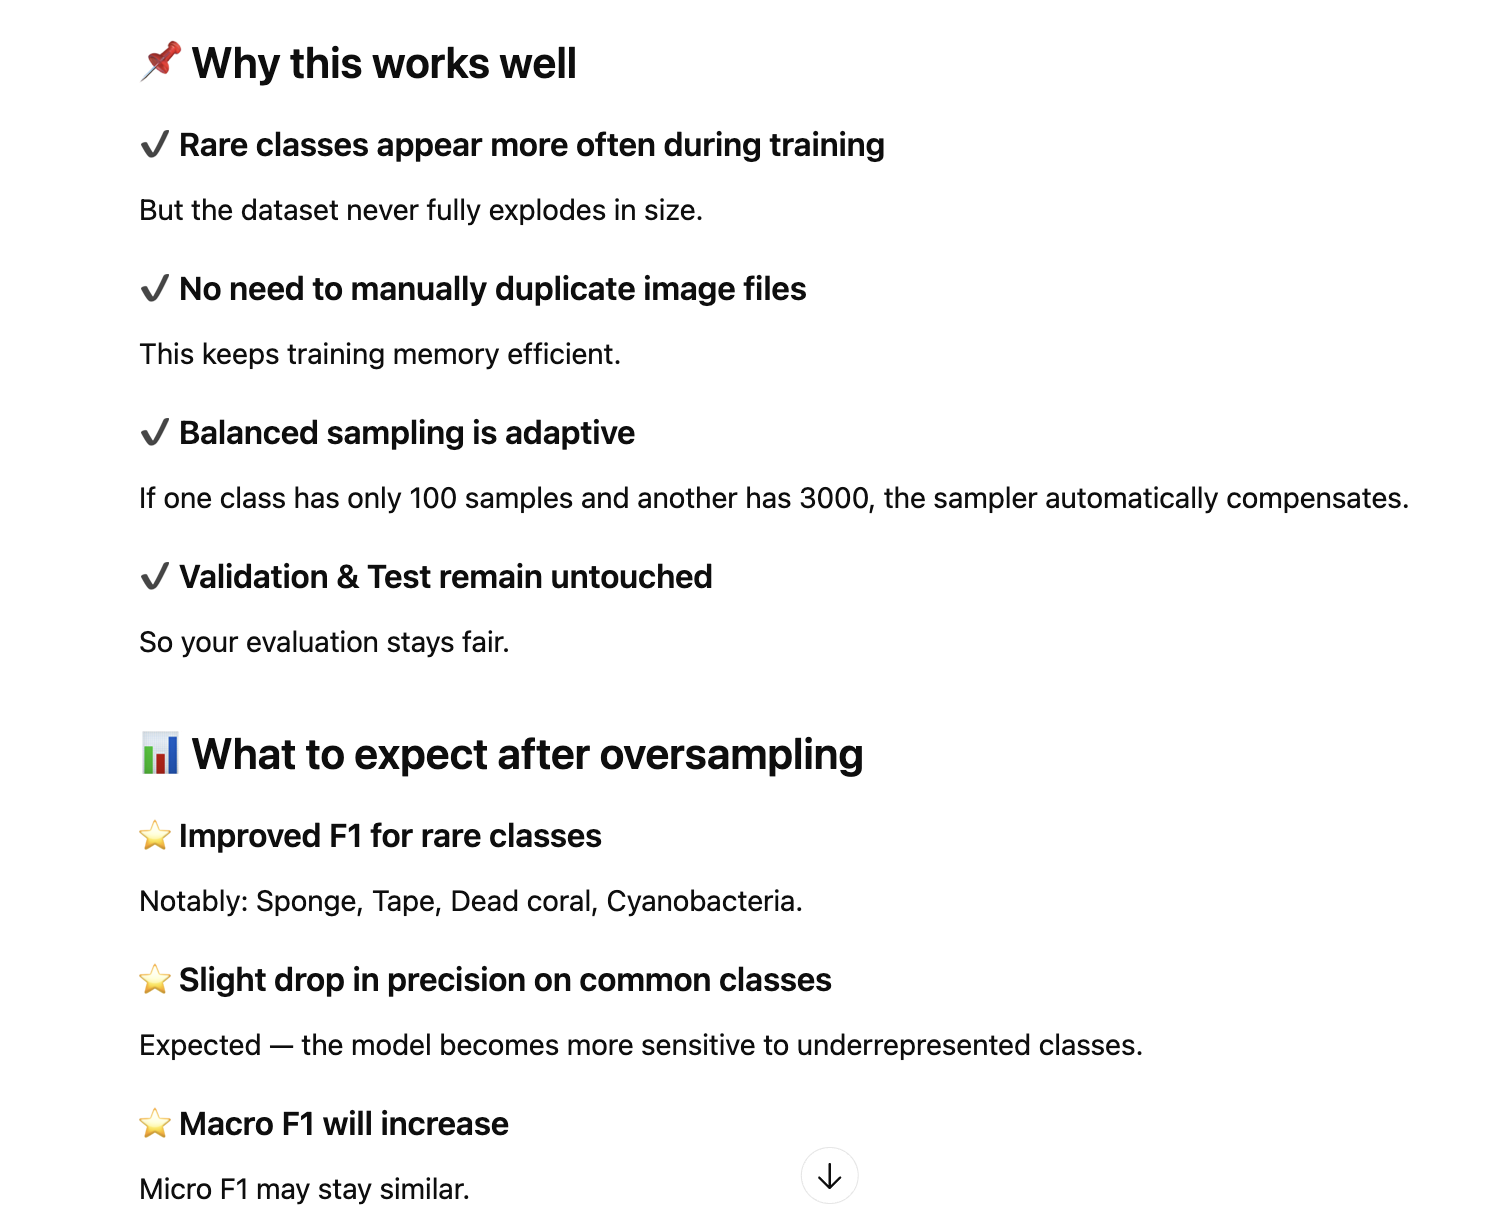

**PATCH_SIZE is simply: the image resize target before feeding into EfficientNet.**

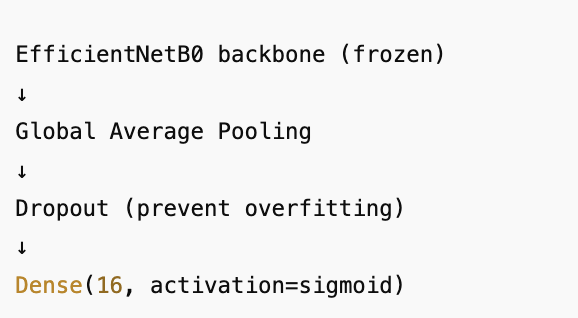

Why BCE is used in multi-label tasks

Because in multi-label classification:

Each class is independent

Each class is a binary yes/no question

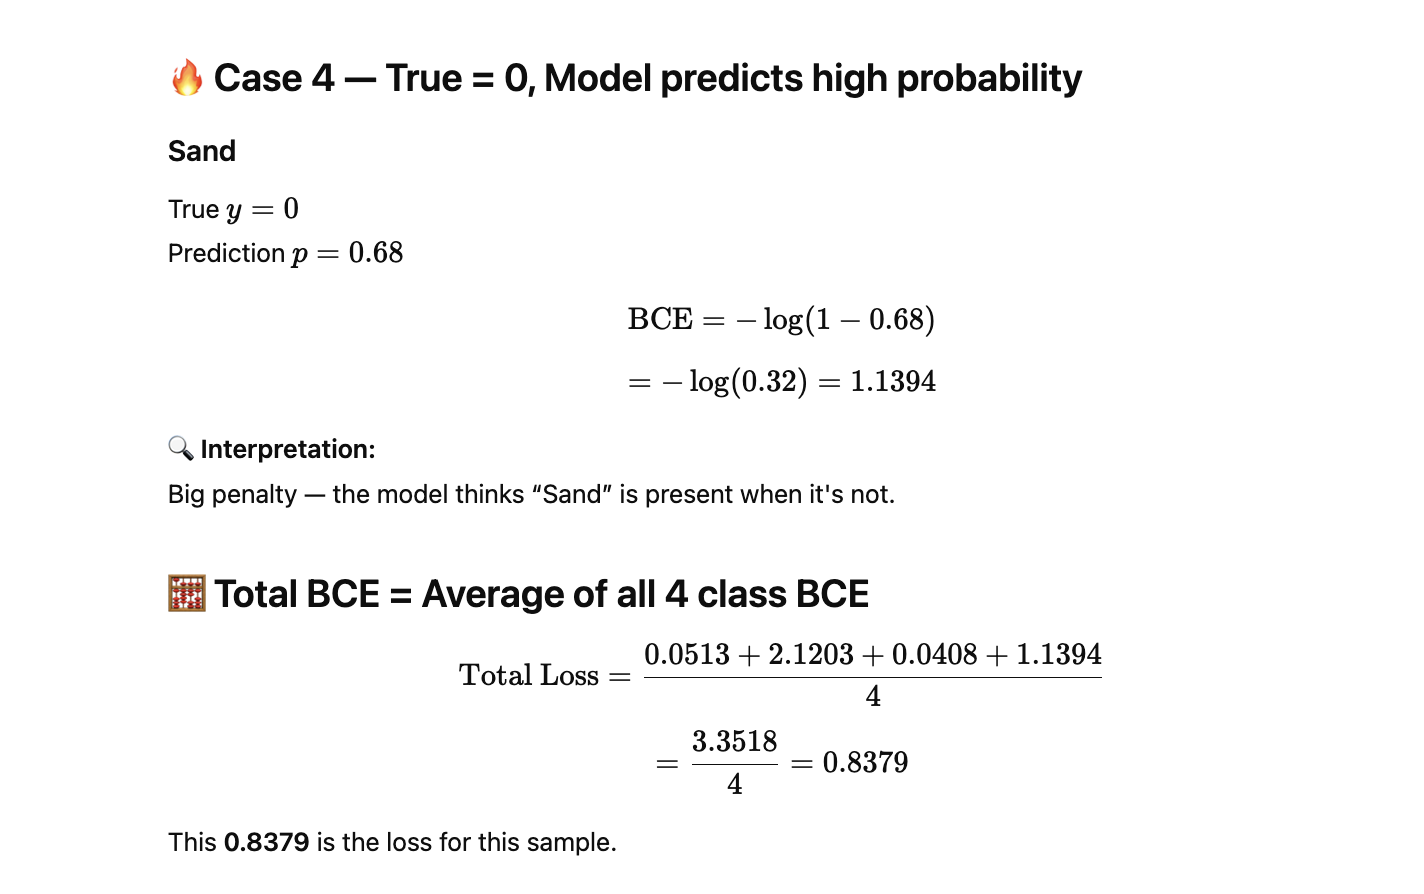

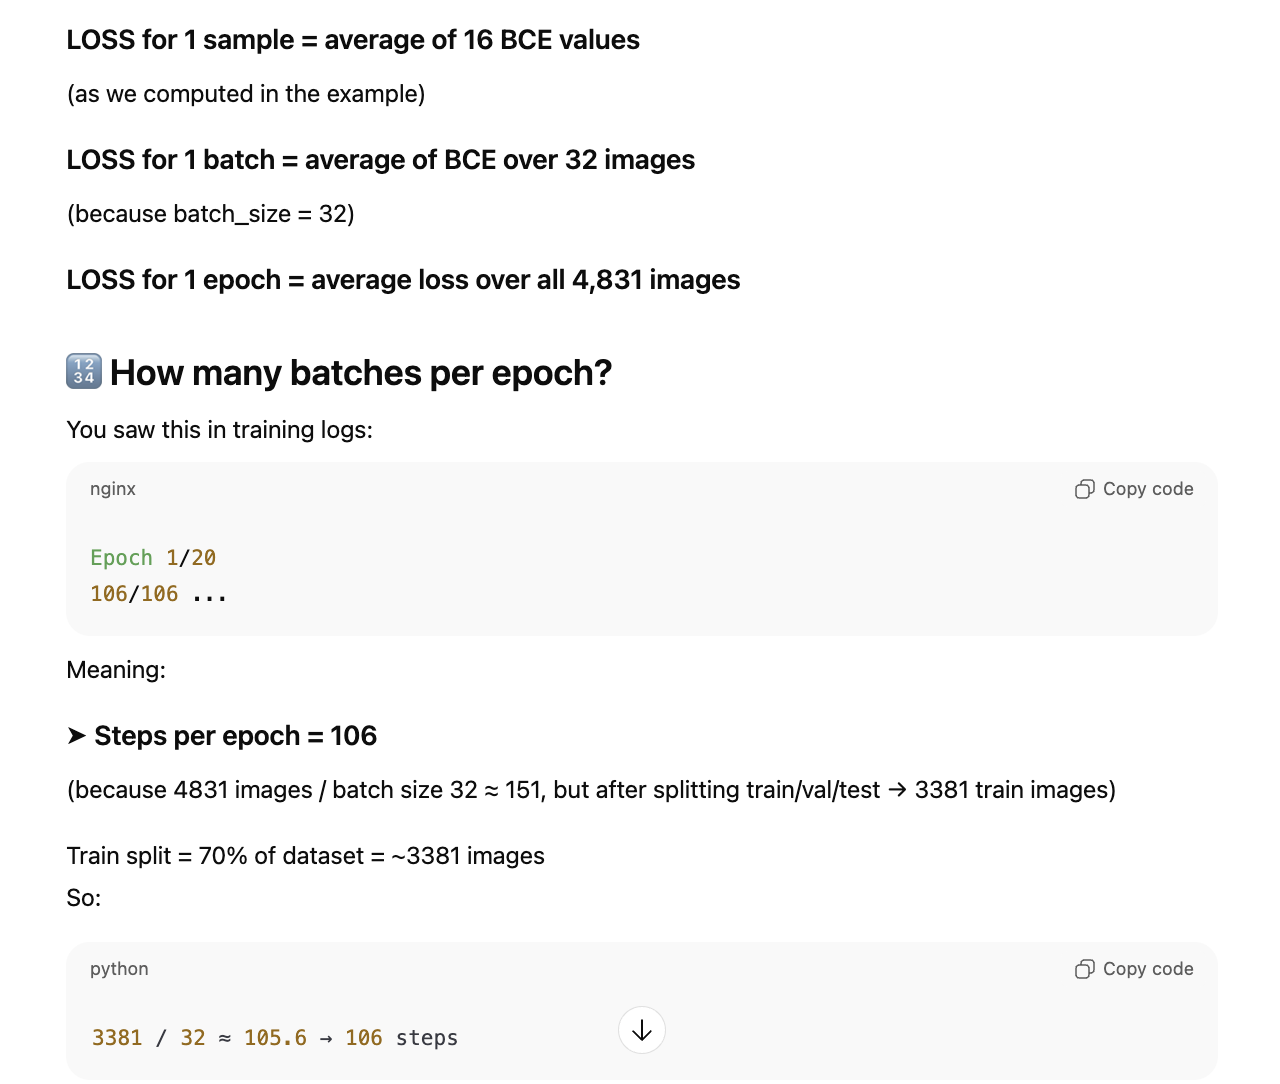

In [ ]:

# ============================================================
# 7. TRAIN — STAGE 1 (Frozen Backbone)
# ============================================================

print("\n===== TRAINING STAGE 1 (Frozen EfficientNet) =====\n")
hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    callbacks=[check1, early],
    verbose=1
)


model = tf.keras.models.load_model(stage1_ckpt)
print("Loaded best Stage 1 checkpoint.\n")





===== TRAINING STAGE 1 (Frozen EfficientNet) =====

Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 429s 5s/step - AUC: 0.6194 - loss: 0.5454 - val_AUC: 0.7635 - val_loss: 0.4225
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 277s 4s/step - AUC: 0.7660 - loss: 0.4524 - val_AUC: 0.7893 - val_loss: 0.4039
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - AUC: 0.7953 - loss: 0.4269 - val_AUC: 0.8017 - val_loss: 0.3907
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step - AUC: 0.8145 - loss: 0.4115 - val_AUC: 0.8089 - val_loss: 0.3847
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step - AUC: 0.8191 - loss: 0.4108 - val_AUC: 0.8163 - val_loss: 0.3820
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step - AUC: 0.8245 - loss: 0.4051 - val_AUC: 0.8243 - val_loss: 0.3747
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step - AUC: 0.8377 - loss: 0.3948 - val_AUC: 0.8266 - val_loss: 0.3724
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 292s 4s/step - AUC: 0.8360 - loss: 0.3926 - val_AUC: 0.8270 - val_loss: 0.3727
Epoch 9/20


In [ ]:
model = tf.keras.models.load_model(stage1_ckpt)
print("Loaded best Stage 1 checkpoint.\n")


Loaded best Stage 1 checkpoint.



In [ ]:

## ============================================================
# 8. TRAIN — STAGE 2 (Fine-Tuning EfficientNet)
# ============================================================

# 1) Load best Stage 1 weights
print("\nLoading best Stage 1 checkpoint...")
model = tf.keras.models.load_model(stage1_ckpt)

# 2) Freeze everything first (safe reset)
for layer in base.layers:
    layer.trainable = False

# 3) Unfreeze top 100 layers
for layer in base.layers[-100:]:
    layer.trainable = True

# 4) Recompile with lower LR and multi-label AUC
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUC", multi_label=True)]
)

print("\n===== TRAINING STAGE 2 (Fine-tuning) =====\n")

# 5) Train Stage 2
hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    callbacks=[check2, early],   # early stopping + best checkpoint
    verbose=1
)

# 6) Load best Stage 2 model
model = tf.keras.models.load_model(stage2_ckpt)
print("\nLoaded best Stage 2 checkpoint.\n")





Loading best Stage 1 checkpoint...

===== TRAINING STAGE 2 (Fine-tuning) =====

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 483s 6s/step - AUC: 0.8606 - loss: 0.3718 - val_AUC: 0.8362 - val_loss: 0.3642
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - AUC: 0.8652 - loss: 0.3658 - val_AUC: 0.8363 - val_loss: 0.3641
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 327s 4s/step - AUC: 0.8577 - loss: 0.3734 - val_AUC: 0.8364 - val_loss: 0.3639
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - AUC: 0.8645 - loss: 0.3666 - val_AUC: 0.8362 - val_loss: 0.3636

Loaded best Stage 2 checkpoint.



In [ ]:

# ============================================================
# 9. EVALUATION (Multi-label metrics)
# ============================================================

print("\n===== EVALUATING ON TEST SET =====\n")
from sklearn.metrics import classification_report, f1_score
pred_prob = model.predict(test_ds)
pred_bin = (pred_prob > 0.5).astype(int)


print("\nClassification Report (threshold=0.5):\n")
print(classification_report(y_test, pred_bin, target_names=CLASSES))


# ============================================================
# 10. Per-class AUC
# ============================================================

print("\n===== PER-CLASS AUC =====")
auc_metric = tf.keras.metrics.AUC()

for i, cname in enumerate(CLASSES):
    auc_metric.reset_state()
    auc_metric.update_state(y_test[:, i], pred_prob[:, i])
    print(f"{cname:30s}  AUC = {auc_metric.result().numpy():.4f}")




===== EVALUATING ON TEST SET =====

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

Classification Report (threshold=0.5):

                          precision    recall  f1-score   support

              Macroalgae       0.41      0.92      0.57       885
                  Rubble       0.46      0.80      0.59       841
Crustose coralline algae       0.81      0.56      0.66      1433
          Bare substrate       0.68      0.39      0.50      1265
                    Sand       0.64      0.67      0.65       816
              Turf algae       0.49      0.14      0.22      1328
                 Porites       0.59      0.37      0.46       590
              Hard coral       0.30      0.31      0.30       334
              Soft coral       0.58      0.14      0.22       870
                Acropora       0.85      0.46      0.59       720
                    Tape       0.00      0.00      0.00       136
             Pocillopora       0.83      0.02      0.03       320
              Dead cora

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Montipora                       AUC = 0.6813
Cyanobacteria                   AUC = 0.7398
Sponge                          AUC = 0.4079


In [ ]:

# ============================================================
# 11. Optimal threshold (per class)
# ============================================================

print("\n===== PER-CLASS OPTIMAL THRESHOLD =====")
import numpy as np
from sklearn.metrics import classification_report, f1_score

def best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.05, 0.95, 20):
        f1 = f1_score(y_true, (y_prob > t).astype(int))
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    return best_t, best_f1

for i, cname in enumerate(CLASSES):
    t, f1 = best_threshold(y_test[:, i], pred_prob[:, i])
    print(f"{cname:25s}  best_t={t:.2f}, best_F1={f1:.3f}")


===== PER-CLASS OPTIMAL THRESHOLD =====
Macroalgae                 best_t=0.10, best_F1=0.576
Rubble                     best_t=0.57, best_F1=0.596
Crustose coralline algae   best_t=0.05, best_F1=0.797
Bare substrate             best_t=0.14, best_F1=0.747
Sand                       best_t=0.43, best_F1=0.675
Turf algae                 best_t=0.05, best_F1=0.754
Porites                    best_t=0.24, best_F1=0.547
Hard coral                 best_t=0.33, best_F1=0.363
Soft coral                 best_t=0.14, best_F1=0.596
Acropora                   best_t=0.33, best_F1=0.666
Tape                       best_t=0.05, best_F1=0.136
Pocillopora                best_t=0.10, best_F1=0.397
Dead coral                 best_t=0.05, best_F1=0.131
Montipora                  best_t=0.19, best_F1=0.232
Cyanobacteria              best_t=0.33, best_F1=0.220
Sponge                     best_t=0.52, best_F1=0.096


In [ ]:
# ============================================================
#     Multi-Label Evaluation with Optimal Thresholds
# ============================================================

import numpy as np
from sklearn.metrics import classification_report, f1_score

# ------------------------------------------------------------
# 1. You already computed these earlier (best thresholds)
#    IMPORTANT: order must match CLASSES exactly.
# ------------------------------------------------------------


best_t = np.array([
    0.10,  # Macroalgae
    0.57,  # Rubble
    0.05,  # Crustose coralline algae
    0.14,  # Bare substrate
    0.43,  # Sand
    0.05,  # Turf algae
    0.24,  # Porites
    0.33,  # Hard coral
    0.14,  # Soft coral
    0.33,  # Acropora
    0.05,  # Tape
    0.10,  # Pocillopora
    0.05,  # Dead coral
    0.19,  # Montipora
    0.33,  # Cyanobacteria
    0.52   # Sponge
])

print("Loaded per-class optimal thresholds:\n")
for cname, t in zip(CLASSES, best_t):
    print(f"{cname:25s}  {t:.2f}")

model = tf.keras.models.load_model(stage2_ckpt)
print("Loaded best Stage 2 checkpoint.\n")

pred_prob = model.predict(test_ds)

# ------------------------------------------------------------
# 2. OLD threshold = 0.5 (what you used before)
# ------------------------------------------------------------

pred_bin_old = (pred_prob > 0.5).astype(int)

# ------------------------------------------------------------
# 3. NEW threshold = best_t (per class)
# ------------------------------------------------------------

pred_bin_new = (pred_prob > best_t).astype(int)

# ------------------------------------------------------------
# 4. Print reports
# ------------------------------------------------------------

print("\n=====================================================")
print("  CLASSIFICATION REPORT — OLD THRESHOLD (0.5)")
print("=====================================================\n")
print(classification_report(y_test, pred_bin_old, target_names=CLASSES))


print("\n=====================================================")
print("  CLASSIFICATION REPORT — OPTIMAL THRESHOLDS")
print("=====================================================\n")
print(classification_report(y_test, pred_bin_new, target_names=CLASSES))


# ------------------------------------------------------------
# 5. Compare Macro F1
# ------------------------------------------------------------

old_macro_f1 = f1_score(y_test, pred_bin_old, average='macro')
new_macro_f1 = f1_score(y_test, pred_bin_new, average='macro')

print("\n=====================================================")
print("                 MACRO F1 COMPARISON")
print("=====================================================")
print(f"Macro F1 (threshold = 0.5):            {old_macro_f1:.4f}")
print(f"Macro F1 (optimal per-class thresh):   {new_macro_f1:.4f}")
print("=====================================================\n")


Loaded per-class optimal thresholds:

Macroalgae                 0.10
Rubble                     0.57
Crustose coralline algae   0.05
Bare substrate             0.14
Sand                       0.43
Turf algae                 0.05
Porites                    0.24
Hard coral                 0.33
Soft coral                 0.14
Acropora                   0.33
Tape                       0.05
Pocillopora                0.10
Dead coral                 0.05
Montipora                  0.19
Cyanobacteria              0.33
Sponge                     0.52
Loaded best Stage 2 checkpoint.

69/69 ━━━━━━━━━━━━━━━━━━━━ 377s 5s/step

  CLASSIFICATION REPORT — OLD THRESHOLD (0.5)

                          precision    recall  f1-score   support

              Macroalgae       0.41      0.92      0.57       885
                  Rubble       0.46      0.80      0.59       841
Crustose coralline algae       0.81      0.56      0.66      1433
          Bare substrate       0.68      0.39      0.50      126

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**evaluate multi-label models using per-class optimal thresholds.**

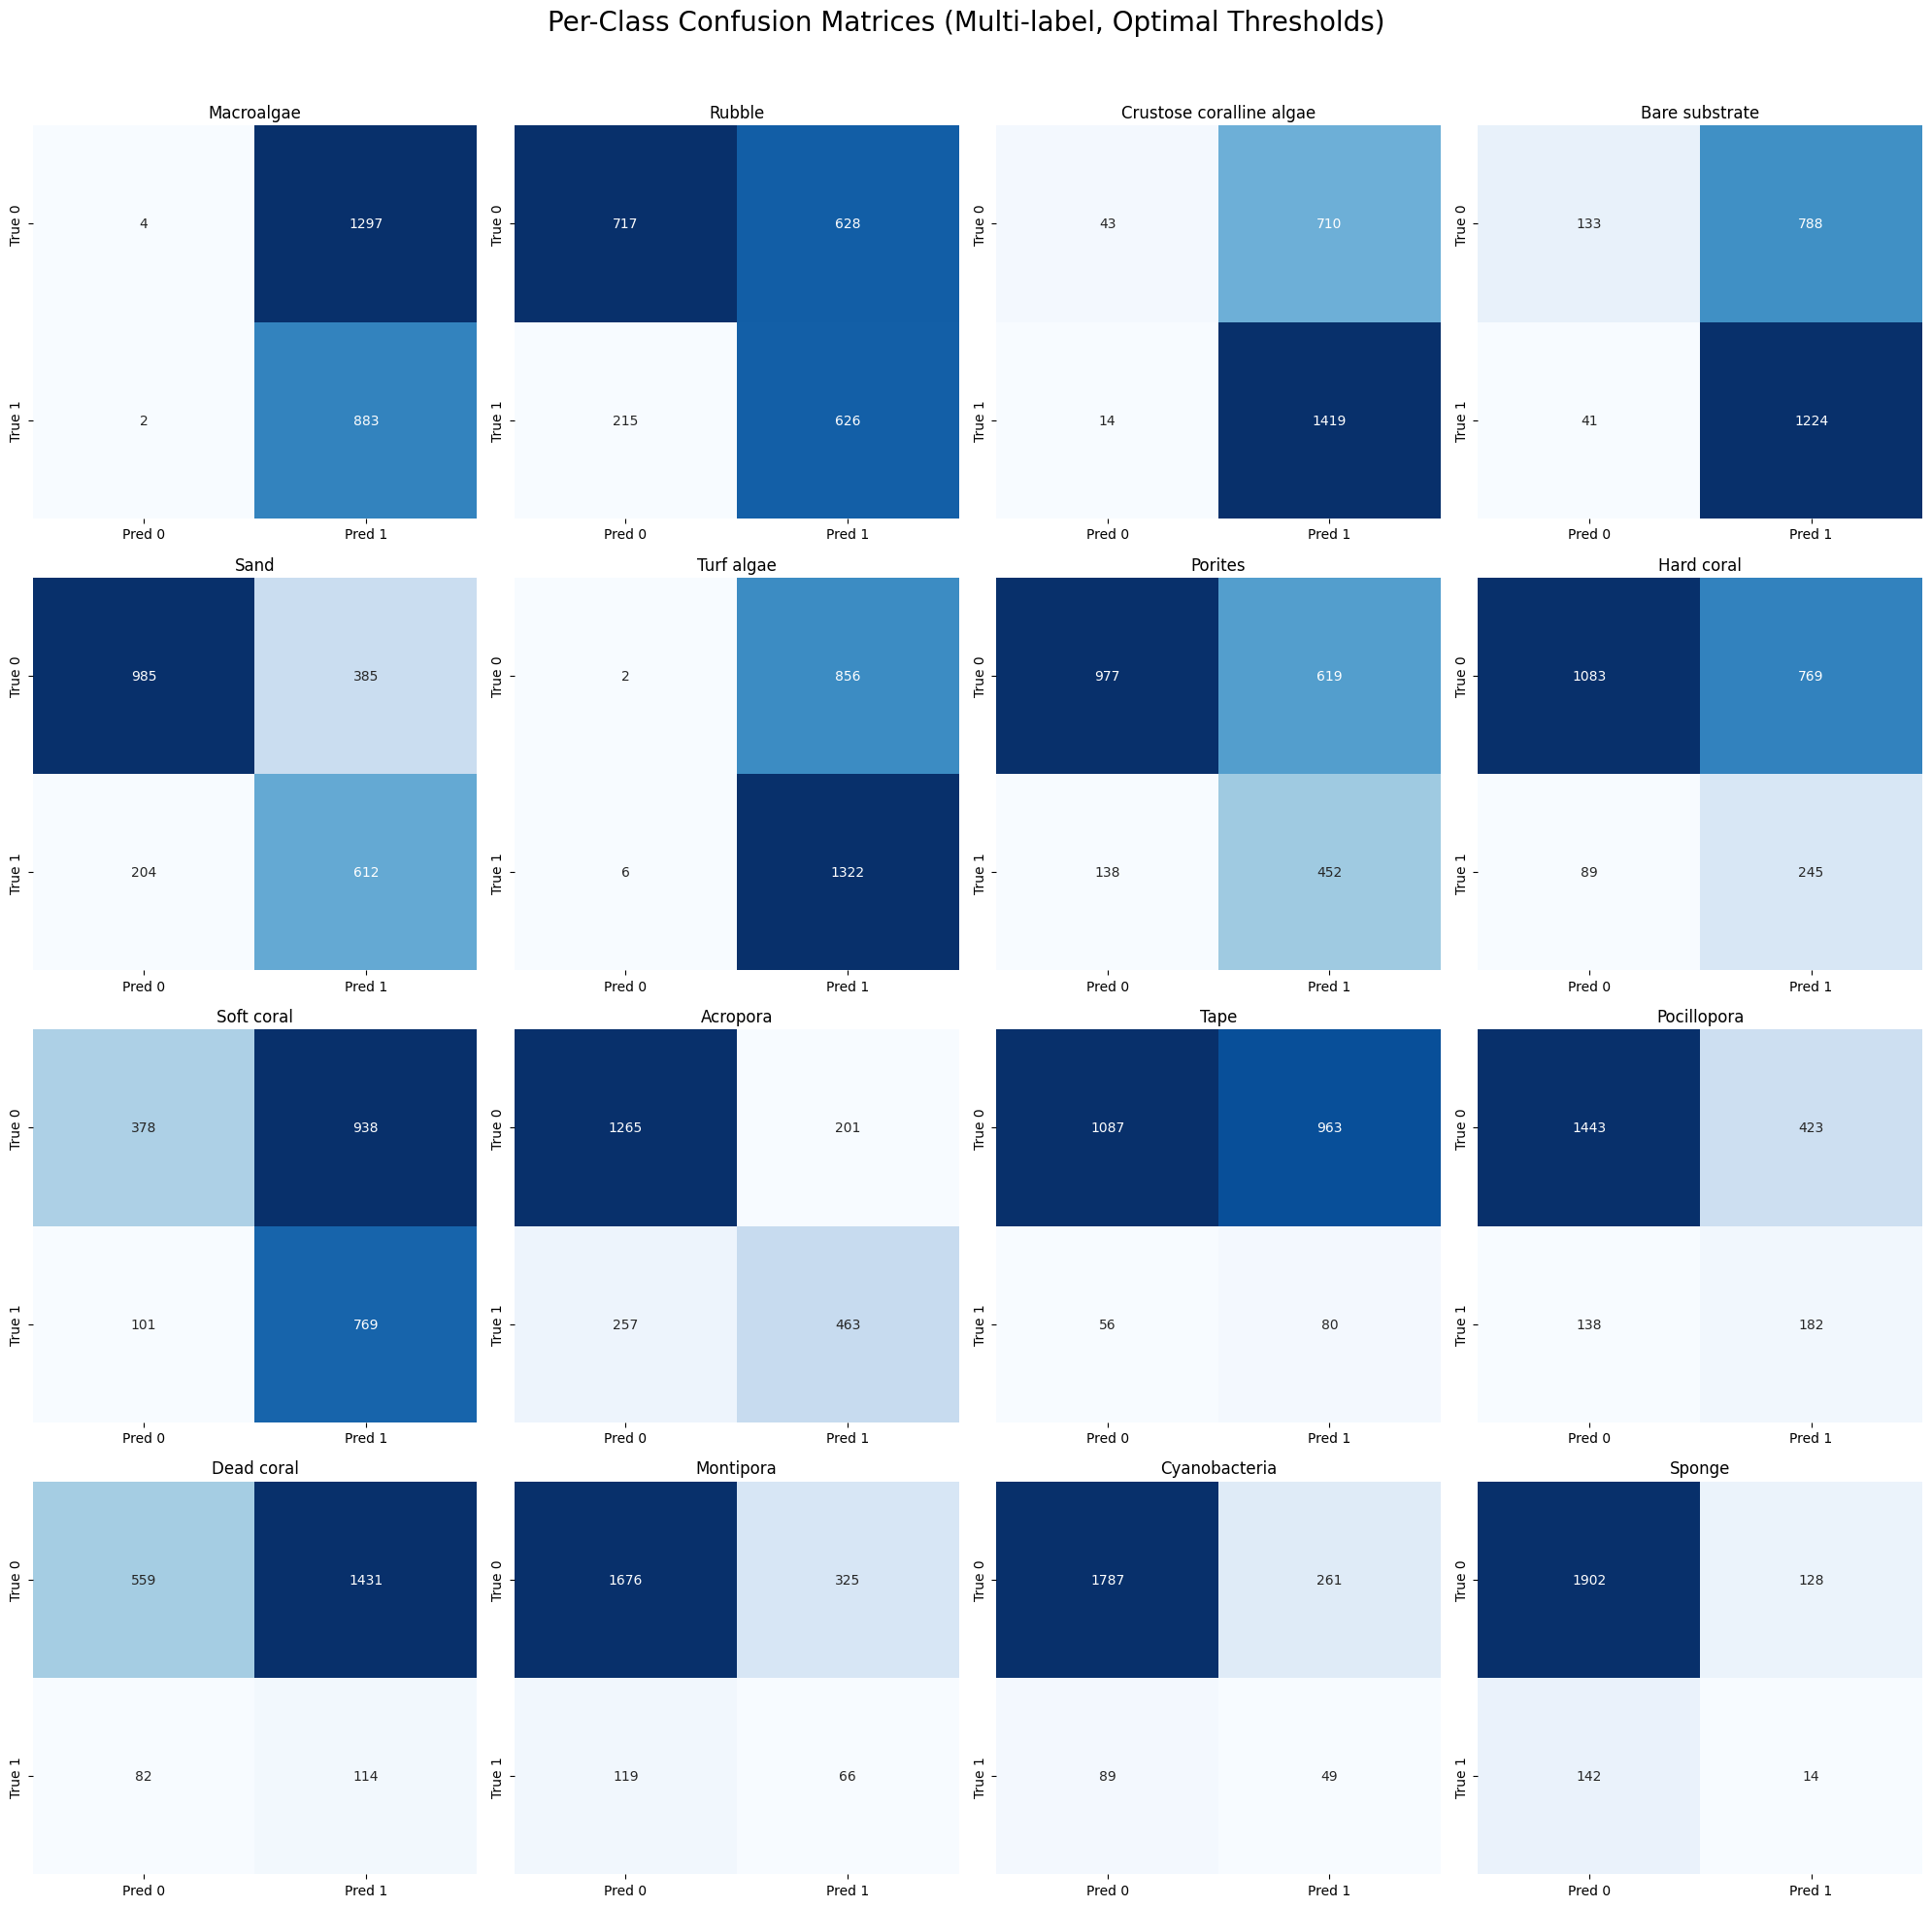

In [ ]:
# ============================================================
#  CONFUSION MATRIX PLOTS — PER-CLASS (Multi-Label)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

num_classes = len(CLASSES)

plt.figure(figsize=(20, 20))
plt.suptitle("Per-Class Confusion Matrices (Multi-label, Optimal Thresholds)", fontsize=20)

for i, cname in enumerate(CLASSES):
    # compute 2×2 confusion matrix for this class
    cm = confusion_matrix(y_test[:, i], pred_bin_new[:, i])

    # Plot each confusion matrix
    plt.subplot(4, 4, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])

    plt.title(cname, fontsize=12)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
